In [ ]:
#!pip install datasets
#!pip install transformers

In [5]:
# import tensorflow as tf
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

**Snippet from assignment**

In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from transformers import BertTokenizer, BertModel, AutoTokenizer

# Load dataset
dataset = load_dataset('ag_news')

# Load model and tokenizer - FINE-TUNED
# model_fineTuned = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4, )
model_fineTuned = BertForSequenceClassification.from_pretrained(
    "./finetuned_model",
    num_labels=4,
    output_attentions=True  # Enable attention outputs
)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
#tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocess data
def preprocess_func(examples):
  return tokenizer(examples['text'], truncation=True, padding="max_length", max_length = 128)

encoded_dataset = dataset.map(preprocess_func, batched=True)
encoded_dataset = encoded_dataset.remove_columns(["text"])  # Keep only model-relevant columns
encoded_dataset = encoded_dataset.rename_column("label", "labels")


# # Training arguments
# training_args= TrainingArguments(
#     output_dir = "./results",
#     evaluation_strategy = "epoch",
#     save_strategy = "epoch",
#     learning_rate = 2e-5,
#     per_device_train_batch_size = 16,
#     num_train_epochs = 3
# )

# trainer = Trainer(
#     model = model_fineTuned,
#     args = training_args,
#     train_dataset = encoded_dataset["train"],
#     eval_dataset = encoded_dataset["test"]
# )

# trainer.train()

# Save the fine-tuned model locally
# model_fineTuned.save_pretrained("./models/fine_tuned_model")

Map: 100%|██████████| 7600/7600 [00:00<00:00, 8011.49 examples/s]


In [10]:
print(dataset["train"].column_names)

from collections import Counter

# Initialize an empty Counter
total_counts = Counter()

# Iterate through all splits in the dataset
for split in dataset:
    labels = dataset[split]["label"]
    total_counts.update(labels)

# Display results
for label, count in total_counts.items():
    print(f"Class {label}: {count} examples")


['text', 'label']
Class 2: 31900 examples
Class 3: 31900 examples
Class 1: 31900 examples
Class 0: 31900 examples


**3.4 - Extracting attention maps**

In [24]:
# Snippet from hand-out, adapted
from transformers import BertTokenizer, BertModel, AutoTokenizer
import torch

# Put models on the same device
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pretrained = BertModel.from_pretrained("bert-base-uncased",
                                             output_attentions=True)


# Move the models to the correct device
model_pretrained.to(device)
model_fineTuned.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_cls_attention_over_layers(attentions, tokens, title):
    """
    Visualize attentions from the [CLS] token to all other tokens across all layers.
    """
    # Extract attention scores for the first head and the [CLS] token (index 0) across all layers
    cls_attentions = [layer[0, 0, 0, :].detach().cpu().numpy() for layer in attentions]
    cls_attentions = np.array(cls_attentions)  # Shape: (12 layers, seq_len)

    # Create a heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(cls_attentions, cmap="viridis", xticklabels=tokens, 
                yticklabels=[f"Layer {i+1}" for i in range(len(cls_attentions))])
    plt.title(title)
    plt.xlabel("Tokens")
    plt.ylabel("Layers")
    plt.xticks(rotation=90)
    plt.show()

def test_first_token(test_tokens):
    # Inspect tokens to see if [CLS] is there (as the first token)
    # ANSWER: Yes, it is.
    
    # Decode the input_ids to check the tokens
    decoded_tokens = tokenizer.decode(test_tokens["input_ids"][0])  # Decode the first sequence

    # Split the decoded tokens into a list for easier inspection
    tokens_list = tokenizer.convert_ids_to_tokens(test_tokens["input_ids"][0])

    # Print the results
    print("Decoded Tokens:", decoded_tokens)
    print("Token List:", tokens_list)

    # Check the first token
    if tokens_list[0] == "[CLS]":
        print("The first token is [CLS].")
    else:
        print("The first token is NOT [CLS].")


def plots(test_tokens):
    # Move the inputs to the correct device
    test_tokens = {key: value.to(device) for key, value in test_tokens.items()}

    #test_first_token(test_tokens)
    
    # Get attentions
    # Pre-trained
    outputs_pretrained = model_pretrained(**test_tokens)
    attentions_pretrained = outputs_pretrained.attentions
    #Fine-tuned
    outputs_fineTuned = model_fineTuned(**test_tokens)
    attentions_fineTuned = outputs_fineTuned.attentions
    
    # Convert token IDs to tokens
    tokens = tokenizer.convert_ids_to_tokens(test_tokens["input_ids"][0])

    # Pre-trained attention
    plot_cls_attention_over_layers(attentions_pretrained,
                                tokens,
                                "Pre-trained Model Attention ([CLS] to All Tokens)\nAcross Layers")

    # Fine-tuned attention
    plot_cls_attention_over_layers(attentions_fineTuned,
                                tokens,
                                "Fine-tuned Model Attention ([CLS] to All Tokens)\nAcross Layers")

Decoded Tokens: [CLS] the massachusetts legislature approved a bill monday aimed at closing loopholes in the state ’ s health care market regulatory process exposed by the collapse of steward health care. [SEP]
Token List: ['[CLS]', 'the', 'massachusetts', 'legislature', 'approved', 'a', 'bill', 'monday', 'aimed', 'at', 'closing', 'loop', '##holes', 'in', 'the', 'state', '’', 's', 'health', 'care', 'market', 'regulatory', 'process', 'exposed', 'by', 'the', 'collapse', 'of', 'steward', 'health', 'care', '.', '[SEP]']
The first token is [CLS].


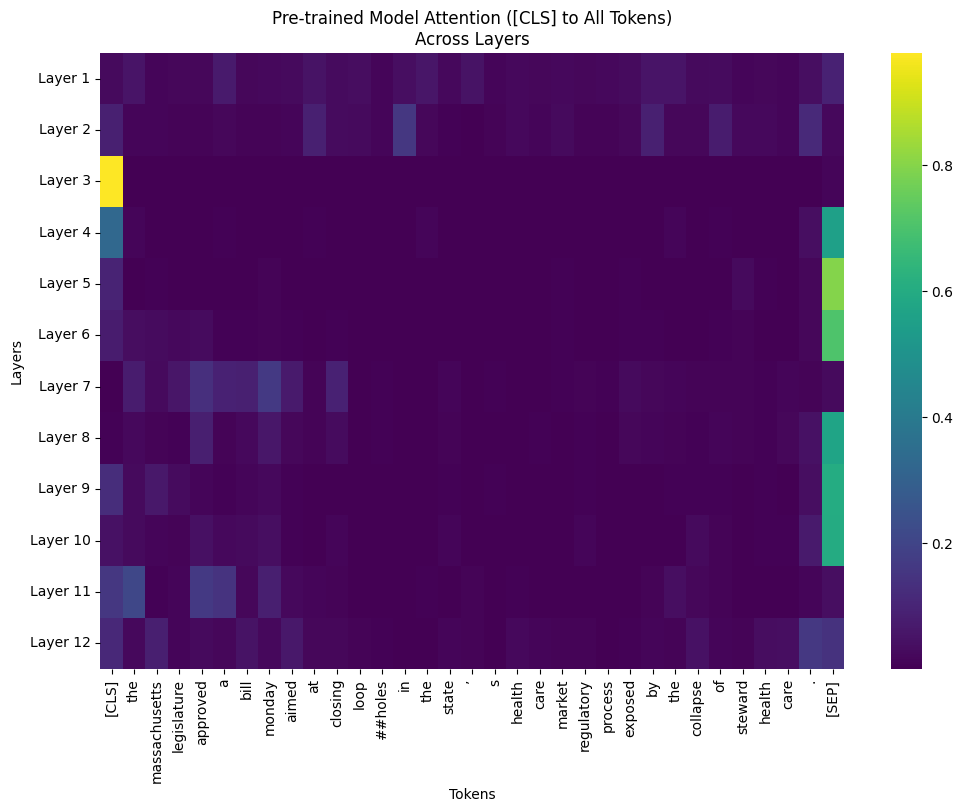

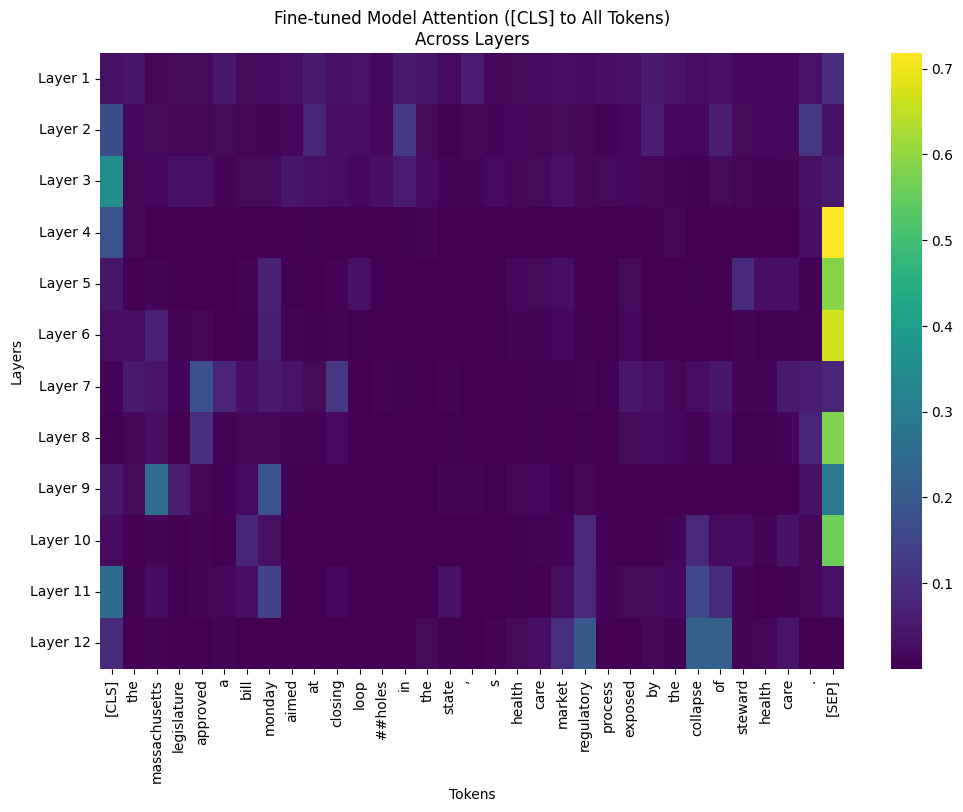

In [29]:
# Example input
test1 = tokenizer("The Massachusetts Legislature approved a bill Monday aimed at closing loopholes in the state’s health care market regulatory process exposed by the collapse of Steward Health Care.", return_tensors="pt")
plots(test1)